In [ ]:
import numpy as np

# Define dimensions
num_channels = 4  # Channels: 1, 2, 3, 4 (indices 0-3)
value_range = (0, 10)  # Values: 0 to 10 (11 values, indices 0-10)
z_range = (0, 11)  # z: 0 to 11 (12 values, indices 0-11)
y_range = (0, 86)  # y: 0 to 86 (87 values, indices 0-86)
x_range = (0, 171)  # x: 0 to 171 (172 values, indices 0-171)

# Calculate array dimensions
num_values = value_range[1] - value_range[0] + 1  # 11 values (0-10)
z_dim = z_range[1] - z_range[0] + 1  # 12 values (0-11)
y_dim = y_range[1] - y_range[0] + 1  # 87 values (0-86)
x_dim = x_range[1] - x_range[0] + 1  # 172 values (0-171)

# Create 5D array initialized with zeros
# Shape: (channel, value, z, y, x)
data = np.zeros((num_channels, num_values, z_dim, y_dim, x_dim), dtype=np.int8)

# Generate random values for each (z, y, x) position
for i in range(0, 4):
    for z in range(z_dim):
        # Channel 0: x ranges 38+40*i to 43+40*i, for all y
        for y in range(y_dim):
            x_start = max(0, 38+20*i)
            x_end = min(x_dim, 43+20*i)
            for x in range(x_start, x_end):
                random_value = np.random.randint(6, 11)
                data[0, random_value, z, y, x] = 1
        # Channel 1: y ranges 18+20*i to 23+20*i, for all x
        y_start = max(0, 18+20*i)
        y_end = min(y_dim, 23+20*i)
        for y in range(y_start, y_end):
            for x in range(x_dim):
                random_value = np.random.randint(6, 11)
                data[1, random_value, z, y, x] = 1
        # Channel 2: 3 diagonal lines with slope 1 (y = x + c)
        strip_width = 3  # Narrower width for diagonal strips
        c_values = [-60, 0, 60]  # 3 lines: y=x-60, y=x, y=x+60
        for c in c_values:
            for y in range(y_dim):
                for x in range(x_dim):
                    if abs(y - x - c) <= strip_width:
                        random_value = np.random.randint(6, 11)
                        data[2, random_value, z, y, x] = 1
        # Channel 3: 3 diagonal lines with slope -1 (y = -x + d)
        strip_width = 3  # Narrower width for diagonal strips
        d_values = [60, 120, 180]  # 3 lines: y=-x+60, y=-x+120, y=-x+180
        for d in d_values:
            for y in range(y_dim):
                for x in range(x_dim):
                    if abs(y + x - d) <= strip_width:
                        random_value = np.random.randint(6, 11)
                        data[3, random_value, z, y, x] = 1

print(f"Created 5D data array with shape: {data.shape}")
print(f"Dimensions breakdown:")
print(f"  - Channels: {num_channels} (1, 2, 3, 4)")
print(f"  - Values: {num_values} (0 to {value_range[1]})")
print(f"  - Z: {z_dim} (0 to {z_range[1]})")
print(f"  - Y: {y_dim} (0 to {y_range[1]})")
print(f"  - X: {x_dim} (0 to {x_range[1]})")
print(f"\nData type: {data.dtype}")
print(f"Total elements: {data.size:,}")
print(f"Memory size: {data.nbytes / 1024 / 1024:.2f} MB")

# Save the data
np.save('groundtruth.npy', data)
print(f"\n✓ 5D data saved to: groundtruth.npy")


Created 5D data array with shape: (4, 11, 12, 87, 172)
Dimensions breakdown:
  - Channels: 4 (1, 2, 3, 4)
  - Values: 11 (0 to 10)
  - Z: 12 (0 to 11)
  - Y: 87 (0 to 86)
  - X: 172 (0 to 171)

Data type: int8
Total elements: 7,900,992
Memory size: 7.53 MB

✓ 5D data saved to: groundtruth.npy


C:\Users\Hossein\AppData\Local\Temp\ipykernel_34180\3216401114.py:24: RuntimeWarning: invalid value encountered in divide
  avg_value_index = np.where(total_sum > 0, weighted_sum / total_sum, 0)  # Shape: (12, 87, 172)


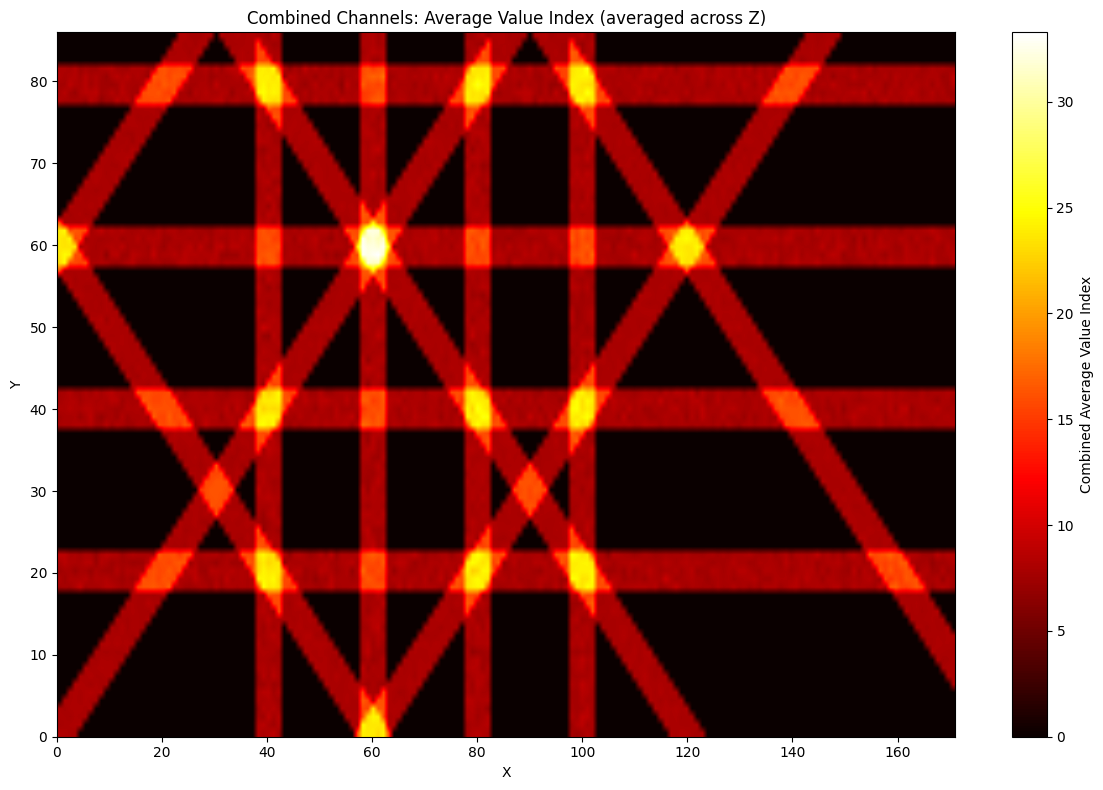


✓ Combined channels visualization
  Image shape: (87, 172)
  Value range: [0.00, 33.28]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load data
data = np.load('groundtruth.npy')
combined_image = np.zeros((y_dim, x_dim), dtype=np.float32)
for channel in range(4):
    channel_data = data[channel]  # Shape: (11, 12, 87, 172)
    value_indices = np.arange(11).reshape(-1, 1, 1, 1)  # Shape: (11, 1, 1, 1)
    weighted_sum = np.sum(value_indices * channel_data, axis=0)  # Shape: (12, 87, 172)
    total_sum = np.sum(channel_data, axis=0)  # Shape: (12, 87, 172)
    avg_value_index = np.where(total_sum > 0, weighted_sum / total_sum, 0)  # Shape: (12, 87, 172)
    avg_z = np.mean(avg_value_index, axis=0)  # Shape: (87, 172)
    combined_image += avg_z
# Plot combined image
plt.figure(figsize=(12, 8))
plt.imshow(combined_image, origin='lower', extent=[0, x_dim-1, 0, y_dim-1], 
           aspect='auto', interpolation='bilinear', cmap='hot')
plt.colorbar(label='Combined Average Value Index')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Combined Channels: Average Value Index (averaged across Z)')
plt.xlim(0, x_dim-1)
plt.ylim(0, y_dim-1)
plt.tight_layout()
plt.show()

print(f"\n✓ Combined channels visualization")
print(f"  Image shape: {combined_image.shape}")
print(f"  Value range: [{combined_image.min():.2f}, {combined_image.max():.2f}]")


In [179]:
import numpy as np
from torch_geometric.data import Data
import torch

# Function to calculate occlusion distance (3D Euclidean distance)
def calculate_occlusion_distance(x1, y1, z1, x2, y2, z2):
    """Calculate 3D Euclidean distance between two points"""
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2)

# OPTIMIZATION 1: Pre-compute intensity matrix for all voxels (one-time computation)
print("Pre-computing intensity matrix...")
import time
start_time = time.time()
intensity_matrix = np.zeros((z_dim, y_dim, x_dim, 4), dtype=np.float32)
for channel in range(4):
    print(f"  Processing channel {channel+1}/4...")
    # Find value indices where data[channel, value_idx, z, y, x] = 1
    channel_data = data[channel]  # Shape: (num_values, z_dim, y_dim, x_dim)
    # For each (z, y, x), find first value index where value=1
    # Use argmax on axis=0 to find first non-zero (since values are 0 or 1)
    value_indices = np.argmax(channel_data, axis=0)  # Shape: (z_dim, y_dim, x_dim)
    # Check if any value is set (sum > 0 means at least one value is 1)
    mask = channel_data.sum(axis=0) > 0  # Shape: (z_dim, y_dim, x_dim)
    # Only use value_indices where mask is True, otherwise 0
    intensity_matrix[:, :, :, channel] = np.where(mask, value_indices.astype(np.float32), 0.0)

elapsed = time.time() - start_time
print(f"✓ Intensity matrix computed in {elapsed:.2f} seconds")

# Parameters
max_radius = 20  # Maximum radius for graph
z_center = 5  # Fixed z coordinate for all graphs
step_size = 10  # Step size for graph centers (optimized with bounding box)

# Generate graph centers with step 10
graph_centers = []
for x in range(0, x_dim, step_size):
    for y in range(0, y_dim, step_size):
        graph_centers.append((x, y, z_center))

print(f"Total graph centers: {len(graph_centers)}")
print(f"Graph centers range: x=[0, {x_dim-step_size}], y=[0, {y_dim-step_size}], z={z_center}")
print(f"Example centers: {graph_centers[:5]}")
print(f"\nStarting graph creation...")

# Create graphs
graphs = []
graph_start_time = time.time()
for center_idx, (center_x, center_y, center_z) in enumerate(graph_centers):
    if center_idx == 0:
        print(f"  Processing first graph...")
    # OPTIMIZED: Only check voxels within bounding box [center ± 20]
    # This reduces from checking all voxels (12×87×172) to only ~40×40×12 per graph
    bounding_radius = 20  # Smaller bounding box for faster computation
    x_min = max(0, int(center_x - bounding_radius))
    x_max = min(x_dim, int(center_x + bounding_radius) + 1)
    y_min = max(0, int(center_y - bounding_radius))
    y_max = min(y_dim, int(center_y + bounding_radius) + 1)
    z_min = max(0, int(center_z - bounding_radius))
    z_max = min(z_dim, int(center_z + bounding_radius) + 1)
    
    # Find all voxels within radius 20 from center (only check bounding box)
    nodes = []
    node_positions = []
    
    for z in range(z_min, z_max):
        for y in range(y_min, y_max):
            for x in range(x_min, x_max):
                # Calculate distance from center
                distance = calculate_occlusion_distance(center_x, center_y, center_z, x, y, z)
                if distance <= max_radius:
                    # OPTIMIZATION 1: Get intensities from pre-computed matrix (fast!)
                    intensities = intensity_matrix[z, y, x, :]  # Shape: (4,)
                    nodes.append(intensities)
                    node_positions.append((x, y, z))
    
    if len(nodes) == 0:
        continue  # Skip empty graphs
    
    # Convert to numpy array
    node_features = np.array(nodes, dtype=np.float32)  # Shape: (num_nodes, 4)
    node_positions_array = np.array(node_positions, dtype=np.int32)  # Shape: (num_nodes, 3)
    num_nodes = len(nodes)
    
    # SUBSAMPLING: Always subsample by factor 2 in each dimension (x, y, z)
    # Example: 30×30×10 nodes → 15×15×5 nodes
    subsample_factor = 2
    
    # Subsample: take every 2nd node in each dimension (x, y, z)
    x_coords = node_positions_array[:, 0]
    y_coords = node_positions_array[:, 1]
    z_coords = node_positions_array[:, 2]
    
    # Create mask for subsampling: keep nodes where (x, y, z) are multiples of 2
    # Adjust relative to the bounding box minimum to maintain spatial structure
    x_min = x_coords.min()
    y_min = y_coords.min()
    z_min = z_coords.min()
    
    mask = ((x_coords - x_min) % subsample_factor == 0) & \
           ((y_coords - y_min) % subsample_factor == 0) & \
           ((z_coords - z_min) % subsample_factor == 0)
    
    # Apply subsampling
    node_features = node_features[mask]
    node_positions_array = node_positions_array[mask]
    node_positions = [tuple(pos) for pos in node_positions_array]
    num_nodes = len(node_features)
    
    # OPTIMIZATION 2: Optimized edge creation (avoid full N×N matrix for large graphs)
    if num_nodes > 1:
        # Use node positions array (already subsampled)
        node_positions_np = node_positions_array.astype(np.float32)  # Shape: (num_nodes, 3)
        
        # For small graphs, use vectorized approach
        # For large graphs, use more memory-efficient approach
        if num_nodes < 500:
            # Vectorized approach (fast for small graphs)
            diff = node_positions_np[:, np.newaxis, :] - node_positions_np[np.newaxis, :, :]
            distances_matrix = np.sqrt(np.sum(diff**2, axis=2))
            edge_mask = (distances_matrix <= max_radius) & (distances_matrix > 0)
            edge_i, edge_j = np.where(edge_mask)
            if len(edge_i) > 0:
                edge_weights_np = 1.0 / (1.0 + distances_matrix[edge_i, edge_j])
            else:
                continue
        else:
            # Memory-efficient approach for large graphs (only compute needed distances)
            edge_i_list = []
            edge_j_list = []
            edge_weights_list = []
            for i in range(num_nodes):
                # Only compute distances to nodes after i (avoid duplicates)
                if i < num_nodes - 1:
                    diff = node_positions_np[i+1:] - node_positions_np[i]
                    distances = np.sqrt(np.sum(diff**2, axis=1))
                    mask = distances <= max_radius
                    if np.any(mask):
                        j_indices = np.where(mask)[0] + i + 1
                        edge_i_list.extend([i] * len(j_indices))
                        edge_j_list.extend(j_indices.tolist())
                        # Add reverse edges
                        edge_i_list.extend(j_indices.tolist())
                        edge_j_list.extend([i] * len(j_indices))
                        # Calculate weights
                        weights = 1.0 / (1.0 + distances[mask])
                        edge_weights_list.extend(weights.tolist())
                        edge_weights_list.extend(weights.tolist())
            
            if len(edge_i_list) == 0:
                continue
            edge_i = np.array(edge_i_list)
            edge_j = np.array(edge_j_list)
            edge_weights_np = np.array(edge_weights_list)
        
        # Convert to PyTorch tensors
        edge_index = torch.tensor(np.stack([edge_i, edge_j]), dtype=torch.long)
        edge_attr = torch.tensor(edge_weights_np, dtype=torch.float32)
    else:
        continue  # Skip graphs with only one node
    
    # Convert node features to PyTorch tensor
    x_tensor = torch.tensor(node_features, dtype=torch.float32)
    
    # Create PyTorch Geometric Data object
    graph = Data(
        x=x_tensor,  # Node features: (num_nodes, 4) - intensities from 4 channels
        edge_index=edge_index,  # Edge connections: (2, num_edges)
        edge_attr=edge_attr,  # Edge weights: (num_edges,) - L = 1/(1+D)
        center=(center_x, center_y, center_z),  # Graph center position
        center_idx=center_idx,  # Index of this graph
        node_positions=node_positions  # Store actual node positions (x, y, z) for each node
    )
    
    graphs.append(graph)
    
    # Progress reporting
    if (center_idx + 1) % 10 == 0:
        elapsed = time.time() - graph_start_time
        print(f"Created {center_idx + 1}/{len(graph_centers)} graphs... (elapsed: {elapsed:.1f}s)")
    elif center_idx == 0:
        elapsed = time.time() - graph_start_time
        print(f"  First graph created in {elapsed:.2f}s")

print(f"\n✓ Created {len(graphs)} graphs")
if len(graphs) > 0:
    print(f"  Average nodes per graph: {np.mean([g.x.shape[0] for g in graphs]):.1f}")
    print(f"  Average edges per graph: {np.mean([g.edge_index.shape[1] for g in graphs]):.1f}")
    print(f"  Total nodes: {sum(g.x.shape[0] for g in graphs):,}")
    print(f"  Total edges: {sum(g.edge_index.shape[1] for g in graphs):,}")
    
    # Save graphs to file in Groundtruth folder
    import os
    groundtruth_folder = r'D:\BIOvisdata\SSGAT\Groundtruth'
    os.makedirs(groundtruth_folder, exist_ok=True)
    save_path = os.path.join(groundtruth_folder, 'graphs_list.pt')
    torch.save(graphs, save_path)
    print(f"\n✓ Saved {len(graphs)} graphs to: {save_path}")
    print(f"  File size: {os.path.getsize(save_path) / 1024 / 1024:.2f} MB")


Pre-computing intensity matrix...
  Processing channel 1/4...
  Processing channel 2/4...
  Processing channel 3/4...
  Processing channel 4/4...
✓ Intensity matrix computed in 0.08 seconds
Total graph centers: 162
Graph centers range: x=[0, 162], y=[0, 77], z=5
Example centers: [(0, 0, 5), (0, 10, 5), (0, 20, 5), (0, 30, 5), (0, 40, 5)]

Starting graph creation...
  Processing first graph...
  First graph created in 0.11s
Created 10/162 graphs... (elapsed: 2.8s)
Created 20/162 graphs... (elapsed: 7.9s)
Created 30/162 graphs... (elapsed: 14.4s)
Created 40/162 graphs... (elapsed: 20.7s)
Created 50/162 graphs... (elapsed: 27.0s)
Created 60/162 graphs... (elapsed: 33.3s)
Created 70/162 graphs... (elapsed: 39.7s)
Created 80/162 graphs... (elapsed: 46.0s)
Created 90/162 graphs... (elapsed: 52.1s)
Created 100/162 graphs... (elapsed: 58.1s)
Created 110/162 graphs... (elapsed: 64.2s)
Created 120/162 graphs... (elapsed: 70.6s)
Created 130/162 graphs... (elapsed: 77.0s)
Created 140/162 graphs...

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
import numpy as np
import os
from tqdm import tqdm
import time

# Define Graph Attention Network model
class INTERACTGAT(nn.Module):
    """
    Graph Attention Network for INTERACT score calculation.
    """
    def __init__(self, in_channels=4, hidden_channels=32, out_channels=1, num_heads=4, dropout=0.1):
        super(INTERACTGAT, self).__init__()
        
        # GAT layers
        self.gat1 = GATConv(
            in_channels=in_channels,
            out_channels=hidden_channels,
            heads=num_heads,
            dropout=dropout,
            concat=True
        )
        
        self.gat2 = GATConv(
            in_channels=hidden_channels * num_heads,
            out_channels=out_channels,
            heads=1,
            dropout=dropout,
            concat=False
        )
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, edge_index, edge_attr=None):
        """
        Forward pass through GAT.
        
        Args:
            x: Node features [N, in_channels]
            edge_index: Graph connectivity [2, E]
            edge_attr: Edge weights [E] (optional)
            
        Returns:
            scores: INTERACT scores [N, 1]
        """
        x = F.elu(self.gat1(x, edge_index, edge_attr))
        x = self.dropout(x)
        scores = self.gat2(x, edge_index, edge_attr)
        return scores

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = INTERACTGAT(in_channels=4, hidden_channels=32, out_channels=1, num_heads=4, dropout=0.1)
model = model.to(device)
model.eval()

print(f"✓ GAT model initialized")
print(f"  Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Note: Using untrained model with random weights")

# Function to calculate INTERACT score
def calculate_interact_score(model, graph, node_positions, R=20, device=device):
    """
    Calculate INTERACT score for each node.
    
    INTERACT formula:
    For each node i, calculate interaction with neighbors j within radius R:
    INTERACT_i = sum_{j: D_ij <= R} [sum over all channel pairs (ch1, ch2)]
                 value_i^(ch1) * value_j^(ch2) * (1/(1+D_ij))
    
    Args:
        model: GAT model
        graph: PyTorch Geometric Data object
        node_positions: List of (x, y, z) positions
        R: Interaction radius (default 20)
        device: torch device
        
    Returns:
        interact_scores: INTERACT scores [N]
        node_values: Node values (sum across channels) [N]
        coordinates: (x, y, z) coordinates
    """
    model.eval()
    with torch.no_grad():
        # Move graph to device
        graph = graph.to(device)
        
        # Get node values: graph.x shape [N, 4] - values for each channel
        node_features = graph.x  # [N, 4]
        node_values = torch.sum(node_features, dim=1)  # [N] - sum across channels
        
        # Get INTERACT scores from GAT
        interact_scores_gat = model(graph.x, graph.edge_index, graph.edge_attr)  # [N, 1]
        interact_scores_gat = interact_scores_gat.squeeze(1)  # [N]
        
        # Calculate explicit INTERACT score based on formula
        num_nodes = graph.x.shape[0]
        node_positions_tensor = torch.tensor(node_positions, dtype=torch.float32, device=device)  # [N, 3]
        
        # Calculate pairwise distances
        pos_i = node_positions_tensor.unsqueeze(1)  # [N, 1, 3]
        pos_j = node_positions_tensor.unsqueeze(0)  # [1, N, 3]
        distances = torch.sqrt(torch.sum((pos_i - pos_j) ** 2, dim=2))  # [N, N]
        
        # Mask for nodes within radius R
        mask = (distances <= R) & (distances > 0)  # [N, N], exclude self
        
        # Calculate INTERACT score: vectorized computation
        # For each node i, calculate: sum_{j: D_ij <= R} [sum_{ch1,ch2} value_i^(ch1) * value_j^(ch2)] * (1/(1+D_ij))
        
        # Calculate link weights: 1/(1+D) for all pairs
        link_weights = 1.0 / (1.0 + distances)  # [N, N]
        link_weights = link_weights * mask.float()  # Apply mask, set self and far nodes to 0
        
        # Calculate channel interaction for all pairs: sum_{ch1,ch2} value_i^(ch1) * value_j^(ch2)
        # node_features: [N, 4]
        # For each pair (i, j): sum over all channel pairs = sum(node_features[i] * node_features[j])
        # Vectorized: compute for all pairs at once
        # node_features[i] * node_features[j] for all i,j: [N, 4] * [N, 4] -> need outer product
        # Use broadcasting: [N, 1, 4] * [1, N, 4] -> [N, N, 4, 4] -> sum over last 2 dims -> [N, N]
        node_i = node_features.unsqueeze(1)  # [N, 1, 4]
        node_j = node_features.unsqueeze(0)  # [1, N, 4]
        channel_interactions = torch.sum(node_i * node_j, dim=2)  # [N, N] - sum over channels
        
        # Multiply by link weights and sum over neighbors
        weighted_interactions = channel_interactions * link_weights  # [N, N]
        interact_scores = torch.sum(weighted_interactions, dim=1)  # [N] - sum over neighbors
        
        # Combine GAT score with explicit INTERACT score
        # Final score = GAT_interact_score + explicit_interact_score
        final_scores = interact_scores_gat + interact_scores
        
        return final_scores.cpu().numpy(), node_values.cpu().numpy(), node_positions

print(f"\n✓ INTERACT score calculation function defined")
print(f"  Formula: INTERACT = sum(neighbors) sum(channel_pairs) value_ch1 * value_ch2 * (1/(1+distance))")
print(f"  Radius R: 20")

# Load graphs from saved file
print("\n" + "="*60)
print("Loading graphs and calculating INTERACT scores...")
print("="*60)

groundtruth_folder = r'D:\BIOvisdata\SSGAT\Groundtruth'
save_path = os.path.join(groundtruth_folder, 'graphs_list.pt')

if os.path.exists(save_path):
    graphs = torch.load(save_path, map_location='cpu', weights_only=False)
    print(f"✓ Loaded {len(graphs)} graphs from: {save_path}")
else:
    print(f"✗ Error: Graph file not found at {save_path}")
    print(f"  Please run graph creation cell first.")
    graphs = []

# Process all graphs and calculate INTERACT scores
if len(graphs) > 0:
    all_results = []  # List to store (x, y, z, interact_score, node_value)
    
    print(f"\nProcessing {len(graphs)} graphs...")
    start_time = time.time()
    
    # Process each graph
    for graph_idx, graph in enumerate(tqdm(graphs, desc="Processing graphs", unit="graph")):
        # Get node positions
        node_positions = graph.node_positions
        
        # Calculate INTERACT scores
        interact_scores, node_values, coordinates = calculate_interact_score(
            model, graph, node_positions, R=20, device=device
        )
        
        # Store results: (x, y, z, interact_score, node_value)
        for node_idx, (x, y, z) in enumerate(coordinates):
            score = interact_scores[node_idx]
            node_value = node_values[node_idx]
            all_results.append((x, y, z, score, node_value))
    
    elapsed = time.time() - start_time
    print(f"\n✓ Processing complete in {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
    print(f"  Total nodes processed: {len(all_results):,}")
    print(f"  Average time per graph: {elapsed/len(graphs):.2f} seconds")
    
    # Sort by INTERACT score in descending order
    all_results.sort(key=lambda item: item[3], reverse=True)  # Sort by score (index 3)
    
    print(f"\n✓ Results sorted by INTERACT score (descending)")
    print(f"\nTop 50 coordinates with maximum INTERACT scores:")
    print(f"{'Rank':<6} {'X':<8} {'Y':<8} {'Z':<8} {'INTERACT Score':<18} {'Node Value':<12}")
    print("-" * 75)
    for rank, (x, y, z, score, node_value) in enumerate(all_results[:50], 1):
        print(f"{rank:<6} {x:<8} {y:<8} {z:<8} {score:<18.6f} {node_value:<12.2f}")
    
    print(f"\n✓ Final list stored in variable 'all_results'")
    print(f"  Format: [(x, y, z, interact_score, node_value), ...]")
    print(f"  Total entries: {len(all_results):,}")
    if len(all_results) > 0:
        print(f"  Score range: [{all_results[-1][3]:.6f}, {all_results[0][3]:.6f}]")
        print(f"  Node value range: [{all_results[-1][4]:.2f}, {all_results[0][4]:.2f}]")
        print(f"\n✓ Maximum INTERACT coordinate:")
        x_max, y_max, z_max, score_max, node_val_max = all_results[0]
        print(f"  Position: (x={x_max}, y={y_max}, z={z_max})")
        print(f"  INTERACT Score: {score_max:.6f}")
        print(f"  Node Value (sum of 4 channels): {node_val_max:.2f}")
else:
    all_results = []
    print("No graphs to process.")


Device: cpu
✓ GAT model initialized
  Model parameters: 1,027
  Note: Using untrained model with random weights

✓ INTERACT score calculation function defined
  Formula: INTERACT = sum(neighbors) sum(channel_pairs) value_ch1 * value_ch2 * (1/(1+distance))
  Radius R: 20

Loading graphs and calculating INTERACT scores...
✓ Loaded 162 graphs from: D:\BIOvisdata\SSGAT\Groundtruth\graphs_list.pt

Processing 162 graphs...


Processing graphs:   2%|▏         | 3/162 [01:19<1:10:31, 26.61s/graph]


KeyboardInterrupt: 